# <a id='toc1_'></a>[Fluorescence lifetimes](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Fluorescence lifetimes](#toc1_)    
  - [cis t1 ideal scenario](#toc1_1_)    
  - [different conditions](#toc1_2_)    
    - [no energy transfers, no dSTORM](#toc1_2_1_)    
    - [no energy transfers, dSTORM](#toc1_2_2_)    
    - [energy transfers, no dSTORM, standard set](#toc1_2_3_)    
    - [energy transfers, no dSTORM, standard set, low irradiance](#toc1_2_4_)    
    - [energy transfers, no dSTORM, no cis ET](#toc1_2_5_)    
    - [energy transfer, no dSTORM, cis 100% recycling](#toc1_2_6_)    
    - [energy transfer, no dSTORM, cis 0.1 rate](#toc1_2_7_)    
    - [energy transfer, no dSTORM, cis 0.05 rate & 0.5 % cis to trans](#toc1_2_8_)    
    - [energy transfer, dSTORM, standard set](#toc1_2_9_)    
    - [energy transfer, dSTORM, lower rate/higher eff OET](#toc1_2_10_)    
    - [energy transfer, no dSTORM, no t1 ET, adj cis ET, standard irradiance](#toc1_2_11_)    
    - [energy transfer, no dSTORM, no t1 ET, adj cis ET, low irradiance](#toc1_2_12_)    
    - [energy transfer, dSTORM, high rate / 0 % recycling](#toc1_2_13_)    
    - [energy transfer, dSTORM, cis adj](#toc1_2_14_)    
    - [energy transfer, dSTORM, cis and t1 adj (nearly ideal)](#toc1_2_15_)    
    - [energy transfer, dSTORM, R ET, 10x R](#toc1_2_16_)    
    - [energy transfer, dSTORM, R ET, 100x R](#toc1_2_17_)    
    - [energy transfer, dSTORM, R ET, 100x R, 3 F](#toc1_2_18_)    
    - [energy transfer, dSTORM, R ET, 100x R, 2 F](#toc1_2_19_)    
    - [energy transfer, dSTORM, R ET, 100x R, 4 F, R ET 2 low](#toc1_2_20_)    
    - [energy transfer, dSTORM, R ET, 100x R, 4 F, R ET 2 medium](#toc1_2_21_)    
    - [kappa sq static regime, no dSTORM, standard set](#toc1_2_22_)    
    - [kappa sq static regime, no dSTORM, cis 0.05 rate & 0.5 % cis to trans](#toc1_2_23_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import fluopy.analysis as an
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.miscellaneous as mi
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

saving_at = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_13_multi_f_et_adjustments\fluorescence_lifetimes"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[cis t1 ideal scenario](#toc0_)

In [ ]:
rng = np.random.default_rng(seed=42)
cis_rate_factors = np.logspace(-4.3, 1, 20)
t1_rate_factors = np.logspace(-4.3, 1, 20)
combinations = np.array(np.meshgrid(cis_rate_factors, t1_rate_factors)).T.reshape(-1, 2)
fl_lifetimes = []
fluorophores = fl.construct_fluorophores(
    name="cy5_dna",
    count=4,
    distance=3,
    shape="square",
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
for val in cis_rate_factors:
    fl_lifetimes.append([])
    for t1_val in t1_rate_factors:
        PARAMS_DSTORM = {
            "irradiance": 2.5,
            "wavelength": 640,
            "dstorm": False,
            "energy_transfer_parameters": {
                "overwrite": {"cis": [val, 0], "t1": [t1_val, 0]},
                "exclude": ["s0"],
            },
        }
        transitions = fluorophore_system.load_transitions(
            bleaching=False,
            summarize=True,
            energy_transfer=True,
            **PARAMS_DSTORM,
        )
        transition_set = tr.TransitionSet(transitions, fluorophore_system)
        transition_set.finalize()
        sim = si.Simulation(transition_set)
        sim.run(
            size=1e8,
            use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
            seed=rng,
        )
        analysis = an.Analysis(sim)
        fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
        fl_lifetimes[-1].append(fluorescence_lifetimes.mean())
        sim.delete_memmaps()

fl_lifetimes = np.array(fl_lifetimes)
np.save(saving_at + r"\cis_t1_ideal.npy", fl_lifetimes)

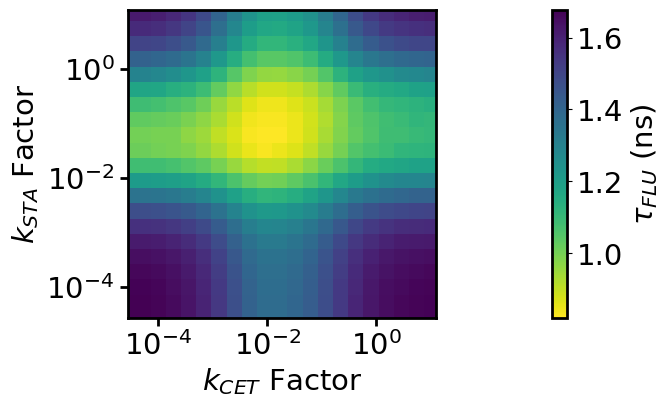

In [20]:
fl_lifetimes = np.load(saving_at + r"\cis_t1_ideal.npy")
fig = plt.figure(figsize=(15, 4))
gs = fig.add_gridspec(1, 1)
ax = fig.add_subplot(gs[0, 0])
fi.universal_figure(axes=ax)
ax.set_aspect("equal", adjustable="box")
cis_rate_factors = np.logspace(-4.3, 1, 20)
t1_rate_factors = np.logspace(-4.3, 1, 20)
x = cis_rate_factors
y = t1_rate_factors
X, Y = np.meshgrid(x, y)
Z = np.array(fl_lifetimes).T
ax.pcolormesh(X, Y, Z, shading="auto", cmap="viridis_r")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$k_{CET}$ Factor", fontsize=21)
ax.set_ylabel(r"$k_{STA}$ Factor", fontsize=21)
ax.set_xticks([1e-4, 1e-2, 1e0])
ax.set_yticks([1e-4, 1e-2, 1e0])
# also show colorbar, with label, larger fontsize of tick labels,
# dont show scientific offset (e.g., 1e9)
cbar = ax.figure.colorbar(
    ax.collections[0],
    ax=ax,
    orientation="vertical",
    pad=0.1,
)
cbar.set_label(r"$\tau_{FLU}$ (ns)", fontsize=21)
cbar.ax.tick_params(labelsize=21)
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_visible(False)

fig = mi.get_figure(ax)
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
bbox_true = ax.get_position()
bbox_true_2 = cbar.ax.get_position()
width1 = bbox_true_2.x1 - bbox_true.x0
width2 = bbox_true_2.x0 - bbox_true.x0
x0 = (1 - width1) / 2
diff = bbox_true.x0 - x0
ax.set_position([x0, bbox_true.y0, bbox_true.width, bbox_true.height])
cbar.ax.set_position(
    [bbox_true_2.x0 - diff, bbox_true_2.y0, bbox_true_2.width, bbox_true_2.height]
)
fig.savefig(
    saving_at + r"\cis_t1_ideal_heatmap.png",
    dpi=300,
    bbox_inches=bbox,
)

## <a id='toc1_2_'></a>[different conditions](#toc0_)

In [2]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna",
    count=4,
    distance=3,
    shape="square",
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

### <a id='toc1_2_1_'></a>[no energy transfers, no dSTORM](#toc0_)

In [ ]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=False,
    irradiance=2.5,
    wavelength=640,
    dstorm=False,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\no_et_no_dstorm.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.25e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.25e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


Mean fluorescence lifetime: 1.70e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.25e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


Mean fluorescence lifetime: 1.70e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.25e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


...

Mean fluorescence lifetime: 1.70e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.25e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


Mean fluorescence lifetime: 1.70e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.25e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


Mean fluorescence lifetime: 1.70e-09 s
Mean fluorescence lifetime: 1.70e-09 s


### <a id='toc1_2_2_'></a>[no energy transfers, dSTORM](#toc0_)

In [230]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=False,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\no_et_dstorm.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.22e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


Mean fluorescence lifetime: 1.69e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.22e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.22e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


Mean fluorescence lifetime: 1.69e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.22e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


...

Mean fluorescence lifetime: 1.69e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.22e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


Mean fluorescence lifetime: 1.69e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.22e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


Mean fluorescence lifetime: 1.69e-09 s
Mean fluorescence lifetime: 1.69e-09 s


### <a id='toc1_2_3_'></a>[energy transfers, no dSTORM, standard set](#toc0_)

In [231]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=False,
    energy_transfer_parameters={"exclude": ["s0"]},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_no_dstorm_standard.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.32e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.31e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.32e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.31e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.31e-09 s
Mean fluorescence lifetime: 1.32e-09 s


### <a id='toc1_2_4_'></a>[energy transfers, no dSTORM, standard set, low irradiance](#toc0_)
low irradiance where acceptor lifetime is irradiance independent leads to less S1 during acceptor lifetime, hence less ET

In [232]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=0.01,
    wavelength=640,
    dstorm=False,
    energy_transfer_parameters={"exclude": ["s0"]},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_no_dstorm_low_irradiance.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.70e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.70e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.70e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.70e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.70e-09 s
Mean fluorescence lifetime: 1.70e-09 s


### <a id='toc1_2_5_'></a>[energy transfers, no dSTORM, no cis ET](#toc0_)
mainly t1 ET responsible for fluorescence lifetime signatures in our standard set

In [233]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=False,
    energy_transfer_parameters={"exclude": ["cis", "s0"]},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_no_dstorm_no_cis.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.35e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.35e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.36e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.35e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.35e-09 s
Mean fluorescence lifetime: 1.36e-09 s


### <a id='toc1_2_6_'></a>[energy transfer, no dSTORM, cis 100% recycling](#toc0_)

In [234]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=False,
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"cis": [1, 0]}},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_no_dstorm_cis_stays_cis.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.29e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.29e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.29e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.29e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.29e-09 s
Mean fluorescence lifetime: 1.30e-09 s


### <a id='toc1_2_7_'></a>[energy transfer, no dSTORM, cis 0.1 rate](#toc0_)

In [235]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=False,
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"cis": [0.1, 0.04]}},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_no_dstorm_cis_01_rate.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.30e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.29e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.30e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.30e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.29e-09 s
Mean fluorescence lifetime: 1.31e-09 s


### <a id='toc1_2_8_'></a>[energy transfer, no dSTORM, cis 0.05 rate & 0.5 % cis to trans](#toc0_)
When lowering cis rate and increasing the recycling rate, fluorescence lifetime signatures become visible

In [236]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=False,
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"cis": [0.05, 0.005]}},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_no_dstorm_cis_005_rate_0005_S0.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.18e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.18e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.19e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.18e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.18e-09 s
Mean fluorescence lifetime: 1.18e-09 s


### <a id='toc1_2_9_'></a>[energy transfer, dSTORM, standard set](#toc0_)

In [237]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"off": [1, 1e-4]}},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_dstorm_standard.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.63e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.64e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.63e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.63e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.63e-09 s
Mean fluorescence lifetime: 1.63e-09 s


### <a id='toc1_2_10_'></a>[energy transfer, dSTORM, lower rate/higher eff OET](#toc0_)
shows that OET has no significant influence on fluorescence lifetimes

In [238]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"off": [0.1, 1e-3]}},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_dstorm_off_01_rate_0001_S0.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.65e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.65e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.64e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.65e-09 s
Mean fluorescence lifetime: 1.65e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.65e-09 s


### <a id='toc1_2_11_'></a>[energy transfer, no dSTORM, no t1 ET, adj cis ET, standard irradiance](#toc0_)

In [239]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=False,
    energy_transfer_parameters={
        "exclude": ["s0", "t1"],
        "overwrite": {"cis": [0.05, 0.005]},
    },
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_no_dstorm_no_sta_cis_adj.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.55e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.55e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.55e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.55e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.55e-09 s
Mean fluorescence lifetime: 1.55e-09 s


### <a id='toc1_2_12_'></a>[energy transfer, no dSTORM, no t1 ET, adj cis ET, low irradiance](#toc0_)
even for only cis, at low irradiances, the ET happens not often enough to leave signature in fluorescence lifetime, even though the cis lifetime is longer. The base thermal isomerization is too fast.

In [240]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=0.01,
    wavelength=640,
    dstorm=False,
    energy_transfer_parameters={
        "exclude": ["s0", "t1"],
        "overwrite": {"cis": [0.05, 0.005]},
    },
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(
    saving_at + r"\et_no_dstorm_low_irradiance_no_sta_cis_adj.npy", lifetime_collection
)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.67e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.68e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.68e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.68e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.68e-09 s
Mean fluorescence lifetime: 1.68e-09 s


### <a id='toc1_2_13_'></a>[energy transfer, dSTORM, high rate / 0 % recycling](#toc0_)
to show that under our standard conditions, dSTORM leads to difference to Trolox even if OFF is immidiately rescued, i.e., coinciding ON states just like Trolox. This is because under dSTORM conditions, the t1 lifetime is smaller, hence STA can not happen that often.

In [241]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"off": [10, 1]}},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_dstorm_off_10_rate_1_S0.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.65e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.65e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.65e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.65e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.65e-09 s
Mean fluorescence lifetime: 1.65e-09 s


### <a id='toc1_2_14_'></a>[energy transfer, dSTORM, cis adj](#toc0_)
larger lifetime than without dSTORM because less STA

In [242]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={
        "exclude": ["s0"],
        "overwrite": {"off": [1, 1e-4], "cis": [0.05, 0.005]},
    },
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_dstorm_cis_adj.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.44e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.44e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.45e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.44e-09 s
Mean fluorescence lifetime: 1.44e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.44e-09 s


### <a id='toc1_2_15_'></a>[energy transfer, dSTORM, cis and t1 adj (nearly ideal)](#toc0_)

In [243]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={
        "exclude": ["s0"],
        "overwrite": {"off": [1, 1e-4], "cis": [0.01, 0], "t1": [0.1, 0]},
    },
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_dstorm_cis_t1_adj.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.17e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.17e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.16e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.17e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.17e-09 s
Mean fluorescence lifetime: 1.17e-09 s


### <a id='toc1_2_16_'></a>[energy transfer, dSTORM, R ET, 10x R](#toc0_)

In [3]:
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"off": [1, 1e-4]}},
)
radical_ET_side = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1e9,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 3), (2, 0), (2, 3), (3, 1), (3, 2)],
)
radical_ET_diag = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1.5e8,
    fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)],
)
transitions["D: cy5_dna, A: cy5_dna, dist: 3.0"].append(radical_ET_side)
transitions["D: cy5_dna, A: cy5_dna, dist: 4.243"].append(radical_ET_diag)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates(change_dict={6: 5e4})

In [244]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"off": [1, 1e-4]}},
)
radical_ET_side = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1e9,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 3), (2, 0), (2, 3), (3, 1), (3, 2)],
)
radical_ET_diag = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1.5e8,
    fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)],
)
transitions["D: cy5_dna, A: cy5_dna, dist: 3.0"].append(radical_ET_side)
transitions["D: cy5_dna, A: cy5_dna, dist: 4.243"].append(radical_ET_diag)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates(change_dict={6: 5e4})
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_dstorm_radical_et_10xR.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.15e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.15e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.14e-09 s
Mean fluorescence lifetime: 1.14e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.14e-09 s
Mean fluorescence lifetime: 1.15e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.15e-09 s
Mean fluorescence lifetime: 1.15e-09 s


### <a id='toc1_2_17_'></a>[energy transfer, dSTORM, R ET, 100x R](#toc0_)

In [245]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"off": [1, 1e-4]}},
)
radical_ET_side = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1e9,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 3), (2, 0), (2, 3), (3, 1), (3, 2)],
)
radical_ET_diag = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1.5e8,
    fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)],
)
transitions["D: cy5_dna, A: cy5_dna, dist: 3.0"].append(radical_ET_side)
transitions["D: cy5_dna, A: cy5_dna, dist: 4.243"].append(radical_ET_diag)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates(change_dict={6: 5e5})
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_dstorm_radical_et_100xR.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 7.20e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 7.14e-10 s
Mean fluorescence lifetime: 7.17e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 7.22e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 7.25e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 7.25e-10 s
Mean fluorescence lifetime: 7.25e-10 s


### <a id='toc1_2_18_'></a>[energy transfer, dSTORM, R ET, 100x R, 3 F](#toc0_)

In [246]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna",
    count=3,
    distance=3,
    shape="square",
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"off": [1, 1e-4]}},
)
radical_ET_side = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1e9,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (2, 0)],
)
radical_ET_diag = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1.5e8,
    fluorophore_ids=[(1, 2), (2, 1)],
)
transitions["D: cy5_dna, A: cy5_dna, dist: 3.0"].append(radical_ET_side)
transitions["D: cy5_dna, A: cy5_dna, dist: 4.243"].append(radical_ET_diag)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates(change_dict={6: 5e5})
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_dstorm_3F_radical_et_100xR.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.91e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.91e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


Mean fluorescence lifetime: 9.25e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.91e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


Mean fluorescence lifetime: 9.26e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.91e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


...

Mean fluorescence lifetime: 9.20e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.91e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


Mean fluorescence lifetime: 9.24e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.91e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


Mean fluorescence lifetime: 9.22e-10 s
Mean fluorescence lifetime: 9.29e-10 s


### <a id='toc1_2_19_'></a>[energy transfer, dSTORM, R ET, 100x R, 2 F](#toc0_)

In [247]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna",
    count=2,
    distance=3,
    shape="square",
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"off": [1, 1e-4]}},
)
radical_ET_side = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1e9,
    fluorophore_ids=[
        (0, 1),
        (1, 0),
    ],
)
transitions["D: cy5_dna, A: cy5_dna, dist: 3.0"].append(radical_ET_side)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates(change_dict={6: 5e5})
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_dstorm_2F_radical_et_100xR.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.06e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.06e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


Mean fluorescence lifetime: 1.07e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.06e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


Mean fluorescence lifetime: 1.07e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.06e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


...

Mean fluorescence lifetime: 1.07e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.06e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


Mean fluorescence lifetime: 1.07e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.06e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.


Mean fluorescence lifetime: 1.08e-09 s
Mean fluorescence lifetime: 1.07e-09 s


### <a id='toc1_2_20_'></a>[energy transfer, dSTORM, R ET, 100x R, 4 F, R ET 2 low](#toc0_)

In [248]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna",
    count=4,
    distance=3,
    shape="square",
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

In [249]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"off": [1, 1e-4]}},
)
radical_ET_side = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1e9,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 3), (2, 0), (2, 3), (3, 1), (3, 2)],
)
radical_ET_diag = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1.5e8,
    fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)],
)
radical_ET2_side = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_2,
    rate=1e5,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 3), (2, 0), (2, 3), (3, 1), (3, 2)],
)
radical_ET2_diag = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_2,
    rate=1.5e4,
    fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)],
)
transitions["D: cy5_dna, A: cy5_dna, dist: 3.0"].extend(
    [radical_ET_side, radical_ET2_side]
)
transitions["D: cy5_dna, A: cy5_dna, dist: 4.243"].extend(
    [radical_ET_diag, radical_ET2_diag]
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates(change_dict={6: 5e5})
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(
    saving_at + r"\et_dstorm_radical_et_100xR_with_rft2_low.npy", lifetime_collection
)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 8.09e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 8.12e-10 s
Mean fluorescence lifetime: 8.09e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 8.10e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 8.11e-10 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 8.13e-10 s
Mean fluorescence lifetime: 8.06e-10 s


### <a id='toc1_2_21_'></a>[energy transfer, dSTORM, R ET, 100x R, 4 F, R ET 2 medium](#toc0_)

In [250]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=True,
    dstorm_parameters={"reducing_agent": "mea", "concentration": 100, "ph": 7.5},
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"off": [1, 1e-4]}},
)
radical_ET_side = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1e9,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 3), (2, 0), (2, 3), (3, 1), (3, 2)],
)
radical_ET_diag = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_1,
    rate=1.5e8,
    fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)],
)
radical_ET2_side = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_2,
    rate=1e6,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 3), (2, 0), (2, 3), (3, 1), (3, 2)],
)
radical_ET2_diag = tr.Transition(
    transition_type=tr.TransitionType.R_FRET_2,
    rate=1.5e5,
    fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)],
)
transitions["D: cy5_dna, A: cy5_dna, dist: 3.0"].extend(
    [radical_ET_side, radical_ET2_side]
)
transitions["D: cy5_dna, A: cy5_dna, dist: 4.243"].extend(
    [radical_ET_diag, radical_ET2_diag]
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates(change_dict={6: 5e5})
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(
    saving_at + r"\et_dstorm_radical_et_100xR_with_rft2_medium.npy", lifetime_collection
)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.25e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.24e-09 s
Mean fluorescence lifetime: 1.24e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.23e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.24e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.25e-09 s
Mean fluorescence lifetime: 1.24e-09 s


### <a id='toc1_2_22_'></a>[kappa sq static regime, no dSTORM, standard set](#toc0_)

In [251]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=False,
    energy_transfer_parameters={"exclude": ["s0"]},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        kap_sq_var=True,
        minimum_rate=1e9,
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_no_dstorm_kap_sq_var.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.24e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.25e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.25e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.25e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.25e-09 s
Mean fluorescence lifetime: 1.25e-09 s


### <a id='toc1_2_23_'></a>[kappa sq static regime, no dSTORM, cis 0.05 rate & 0.5 % cis to trans](#toc0_)

In [252]:
rng = np.random.default_rng(seed=42)
lifetime_collection = []
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    irradiance=2.5,
    wavelength=640,
    dstorm=False,
    energy_transfer_parameters={"exclude": ["s0"], "overwrite": {"cis": [0.05, 0.005]}},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
for _ in range(10):
    sim = si.Simulation(transition_set)
    sim.run(
        kap_sq_var=True,
        minimum_rate=1e9,
        size=1e8,
        use_memmap=r"C:\Users\vie43sq\data_vincent\python_output\memmaps\run_1",
        seed=rng,
    )
    analysis = an.Analysis(sim)
    fluorescence_lifetimes = analysis.get_emitting_transition_lifetimes("cy5_dna")
    lifetime_collection.append(fluorescence_lifetimes.mean())
    print(f"Mean fluorescence lifetime: {fluorescence_lifetimes.mean():.2e} s")
    sim.delete_memmaps()
lifetime_collection = np.array(lifetime_collection)
np.save(saving_at + r"\et_no_dstorm_cis_adj_kap_sq_var.npy", lifetime_collection)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.20e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.20e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


...

Mean fluorescence lifetime: 1.20e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.20e-09 s


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 9.58e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


Mean fluorescence lifetime: 1.20e-09 s
Mean fluorescence lifetime: 1.20e-09 s


In [ ]:
saving_at = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_13_multi_f_et_adjustments\fluorescence_lifetimes"
for file in Path(saving_at).iterdir():
    if file.suffix != ".npy":
        continue
    data = np.load(file)
    print(f"{file.name}: mean = {data.mean():.2e} s, std = {data.std():.2e} s")

et_dstorm_2F_radical_et_100xR.npy: mean = 1.07e-09 s, std = 4.12e-12 s
et_dstorm_3F_radical_et_100xR.npy: mean = 9.24e-10 s, std = 3.25e-12 s
et_dstorm_cis_adj.npy: mean = 1.44e-09 s, std = 1.07e-12 s
et_dstorm_cis_t1_adj.npy: mean = 1.17e-09 s, std = 1.44e-12 s
et_dstorm_off_01_rate_0001_S0.npy: mean = 1.65e-09 s, std = 6.53e-13 s
et_dstorm_off_10_rate_1_S0.npy: mean = 1.65e-09 s, std = 1.98e-13 s
et_dstorm_radical_et_100xR.npy: mean = 7.22e-10 s, std = 3.70e-12 s
et_dstorm_radical_et_100xR_with_rft2_low.npy: mean = 8.10e-10 s, std = 3.29e-12 s
et_dstorm_radical_et_100xR_with_rft2_medium.npy: mean = 1.24e-09 s, std = 3.98e-12 s
et_dstorm_radical_et_10xR.npy: mean = 1.14e-09 s, std = 4.75e-12 s
et_dstorm_standard.npy: mean = 1.63e-09 s, std = 1.96e-12 s
et_no_dstorm_cis_005_rate_0005_S0.npy: mean = 1.18e-09 s, std = 3.47e-12 s
et_no_dstorm_cis_01_rate.npy: mean = 1.30e-09 s, std = 4.73e-12 s
et_no_dstorm_cis_adj_kap_sq_var.npy: mean = 1.20e-09 s, std = 2.77e-12 s
et_no_dstorm_cis_stays